In [1]:
%pip install -qU ddgs arxiv langchain-community langchain langchain-google-community\[gmail\]

Note: you may need to restart the kernel to use updated packages.


In [2]:
from dotenv import load_dotenv 

load_dotenv()

True

In [3]:
from langchain.chat_models.base import init_chat_model

llm = init_chat_model(model="gpt-4o-mini", model_provider="openai")

In [4]:
from langchain_core.tools import tool 

# @tool: 데코레이터를 사용하여 도구 정의
# add: 도구의 이름
# description: 도구에 대한 설명
# a, b: 도구가 받을 매개변수
# return: 도구가 반환하는 값의 타입(Expected Argument)
@tool 
def add(a: int, b: int) -> int:
    """숫자 a와 b를 더합니다."""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """숫자 a와 b를 곱합니다."""
    return a * b

In [5]:
from langchain_community.tools import DuckDuckGoSearchRun 

search_tool = DuckDuckGoSearchRun()

In [6]:
search_tool 

DuckDuckGoSearchRun(api_wrapper=DuckDuckGoSearchAPIWrapper(region='wt-wt', safesearch='moderate', time='y', max_results=5, backend='auto', source='text'))

In [7]:
from langchain_google_community import GmailToolkit

from langchain_google_community.gmail.utils import (
    build_resource_service,
    get_gmail_credentials,
)

credentials = get_gmail_credentials(
    token_file="./google/gmail_token.json",
    scopes=["https://mail.google.com/"],
    client_sercret_file="./google/gmail_credentials.json",
)
api_resource = build_resource_service(credentials=credentials)
gmail_toolkit = GmailToolkit(api_resource=api_resource)

gmail_tool_list = gmail_toolkit.get_tools()

/var/folders/z0/1s99gknj53x_1hd6ndb09frh0000gn/T/ipykernel_59154/4172087591.py:8: DeprecationWarning: get_gmail_credentials is deprecated and will be removed in a future version.Use get_google_credentials instead.
  credentials = get_gmail_credentials(
/var/folders/z0/1s99gknj53x_1hd6ndb09frh0000gn/T/ipykernel_59154/4172087591.py:13: DeprecationWarning: build_resource_service is deprecated and will be removed in a future version.Use build_gmail_service instead.
  api_resource = build_resource_service(credentials=credentials)


In [8]:
gmail_tool_list

[GmailCreateDraft(api_resource=<googleapiclient.discovery.Resource object at 0x130c3c710>),
 GmailSendMessage(api_resource=<googleapiclient.discovery.Resource object at 0x130c3c710>),
 GmailSearch(api_resource=<googleapiclient.discovery.Resource object at 0x130c3c710>),
 GmailGetMessage(api_resource=<googleapiclient.discovery.Resource object at 0x130c3c710>),
 GmailGetThread(api_resource=<googleapiclient.discovery.Resource object at 0x130c3c710>)]

In [9]:
from langchain_community.tools.arxiv.tool import ArxivQueryRun 

arxiv_tool = ArxivQueryRun()


In [10]:
from langgraph.prebuilt import ToolNode 

tool_list = [add, multiply, search_tool, arxiv_tool] + gmail_tool_list
llm_with_tools = llm.bind_tools(tool_list)
tool_node = ToolNode(tool_list)

In [11]:
from langgraph.graph import MessagesState, StateGraph 

class AgentState(MessagesState):
    summary: str

graph_builder = StateGraph(AgentState)

In [12]:
from langchain_core.messages import SystemMessage 

def agent(state: AgentState): 
    messages = state['messages'] 
    summary = state['summary']
    if summary != '':
        messages = [SystemMessage(content=f'Here is the summary of the earlier conversation: {summary}')] + messages 

    response = llm_with_tools.invoke(messages) # messages: 전체 history -> token과 비용이 많이 든다.
    return {'messages': [response]}

In [13]:
from langchain_core.messages import RemoveMessage

def delete_messages(state: AgentState):
    messages = state['messages']
    delete_messages = [RemoveMessage(id=message.id) for message in messages[:-3]]
    return {'messages': delete_messages}

In [14]:
def should_continue(state: AgentState):
    messages = state['messages']
    last_ai_message = messages[-1]
    if last_ai_message.tool_calls:
        return 'tools'
    return 'summarize_messages'

In [15]:
def summarize_messages(state: AgentState):
    messages = state['messages']
    summary = state['summary']
    summary_prompt = f'''summarize this chat history below: \n\nchat_history: {messages}'''
    if summary != '':
        summary_prompt = f'''summarize this chat history below while looking at the summary of earlier conversations
        chat_history: {messages}
        summary: {summary}
    ''' 

    summary = llm.invoke(summary_prompt)
    response = llm_with_tools.invoke(summary_prompt)
    return {'summary': response.content}

In [16]:
graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node)
graph_builder.add_node(delete_messages)
graph_builder.add_node(summarize_messages)


In [17]:
from langgraph.graph import START, END 

graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    should_continue,
    ['tools', 'summarize_messages']
)
graph_builder.add_edge('tools', 'agent')
graph_builder.add_edge('summarize_messages', 'delete_messages')
graph_builder.add_edge('delete_messages', END)

In [18]:
from langgraph.checkpoint.memory import MemorySaver 

checkpointer = MemorySaver()


graph = graph_builder.compile(
    checkpointer=checkpointer
)

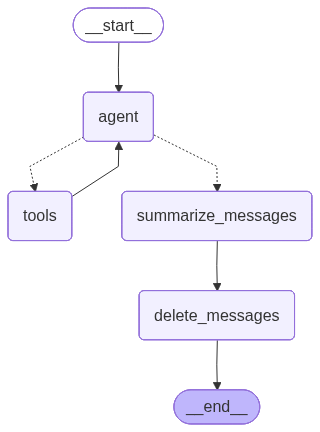

In [19]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
from langchain_core.messages import HumanMessage

config = {
    'configurable': {
        'thread_id': 'paper_summary'
    }
}

query = 'yongbum10002@gmail.com 으로 Attention Is All You Need 논문을 요약해서 이메일 초안을 작성해주세요.'

for chunk in graph.stream({'messages': [HumanMessage(query)], 'summary': ''}, config=config, stream_mode='values'):
    chunk['messages'][-1].pretty_print()



================================ Human Message =================================

yongbum10002@gmail.com 으로 Attention Is All You Need 논문을 요약해서 이메일 초안을 작성해주세요.
================================== Ai Message ==================================
Tool Calls:
  arxiv (call_kqthA69IsI8qmx1NUHsK7KYr)
 Call ID: call_kqthA69IsI8qmx1NUHsK7KYr
  Args:
    query: Attention Is All You Need
================================= Tool Message =================================
Name: arxiv

Published: 2024-07-22
Title: Attention Is All You Need But You Don't Need All Of It For Inference of Large Language Models
Authors: Georgy Tyukin, Gbetondji J-S Dovonon, Jean Kaddour, Pasquale Minervini
Summary: The inference demand for LLMs has skyrocketed in recent months, and serving
models with low latencies remains challenging due to the quadratic input length
complexity of the attention layers. In this work, we investigate the effect of
dropping MLP and attention layers at inference time on the performance of
Llama-v2

In [21]:
# update_query = '논문의 출처 url을 첨부해주세요.'

# for chunk in graph.stream({'messages': [HumanMessage(update_query)]}, config=config, stream_mode='values'):
#     chunk['messages'][-1].pretty_print()

In [22]:
# send_query = '초안이 좋습니다. 이메일을 전송해주세요.'
# for chunk in graph.stream({'messages': [HumanMessage(send_query)]}, config=config, stream_mode='values'):
#     chunk['messages'][-1].pretty_print()

In [23]:
# history 관리 
# 1. 초기 메시지를 삭제하는 방법 (manual)
# 2. 삭제 하기 전에 요약을 해서, 요약본을 초기 메시지로 대체하는 방법 (node)

In [24]:
current_message_list = graph.get_state(config).values['messages']
current_message_list

[AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 341, 'prompt_tokens': 1459, 'total_tokens': 1800, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1408}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_560af6e559', 'id': 'chatcmpl-CXijFn3YsnI0ma9zeXpSWFq34YQWu', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--d512bed7-2901-4b61-b3da-48bbda01faf0-0', tool_calls=[{'name': 'create_gmail_draft', 'args': {'message': "안녕하세요,\n\n논문 'Attention Is All You Need'에 대한 요약을 아래에 기재합니다.\n\n이 연구에서는 대형 언어 모델(LLM)의 추론 요구가 급격히 증가하고 있으며, 낮은 지연 시간으로 모델을 제공하는 것이 여전히 도전이라는 점을 다룹니다. 특히 주목(attention) 계층의 입력 길이에 대한 복잡도 때문에 이러한 문제가 발생하고 있습니다. 연구 결과, 추론 시 MLP(다층 퍼셉트론) 및 주목 계층을 제거하는 것이 Llama-v2 모델의 성능에 미치는 영향을 조사

In [25]:
graph.get_state(config).values['summary']

'In the chat, the user requested a summary of the research paper "Attention Is All You Need" to be drafted into an email addressed to their Gmail account. The assistant initiated a search on Arxiv for work related to the paper and retrieved three relevant summaries of related research papers. \n\nThe first paper discussed challenges in serving large language models with low latencies and the effects of removing MLP and attention layers during inference. The second paper examined the role of self-attention in hybrid architectures for retrieval tasks. The third explored attention mechanisms in image retrieval.\n\nSubsequently, the assistant created a draft email summarizing the findings from the first paper, highlighting the main findings about the inference demands for large language models and the performance impacts of removing attention layers. The user was informed that the email draft was ready for sending or further editing.'

In [26]:
# from langchain_core.messages import RemoveMessage 

# for index, message in enumerate(current_message_list):
#     if index < len(current_message_list) - 1:
#         graph.update_state(config, {'messages': RemoveMessage(id=message.id)})

In [27]:
current_message_list = graph.get_state(config).values['messages']
current_message_list

[AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 341, 'prompt_tokens': 1459, 'total_tokens': 1800, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1408}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_560af6e559', 'id': 'chatcmpl-CXijFn3YsnI0ma9zeXpSWFq34YQWu', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--d512bed7-2901-4b61-b3da-48bbda01faf0-0', tool_calls=[{'name': 'create_gmail_draft', 'args': {'message': "안녕하세요,\n\n논문 'Attention Is All You Need'에 대한 요약을 아래에 기재합니다.\n\n이 연구에서는 대형 언어 모델(LLM)의 추론 요구가 급격히 증가하고 있으며, 낮은 지연 시간으로 모델을 제공하는 것이 여전히 도전이라는 점을 다룹니다. 특히 주목(attention) 계층의 입력 길이에 대한 복잡도 때문에 이러한 문제가 발생하고 있습니다. 연구 결과, 추론 시 MLP(다층 퍼셉트론) 및 주목 계층을 제거하는 것이 Llama-v2 모델의 성능에 미치는 영향을 조사